In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

In [ ]:
# =============================================================================
# USER CONFIGURATION -- KC_TLS_10x
# =============================================================================

SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/K")

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/klc_tls_spacross/K")

CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

ALL_KC_TLS_SAMPLES = ["KC1", "KC2", "KC3"]

SAMPLES_TO_RUN = "all"

METHOD_NAME = "SpaCross"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# Fixed spatial domains for KC_TLS
NUM_CLUSTERS_KC_TLS = 4

GT_LABEL_COL = "z"
SPATIAL_KEY = "S"


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_KC_TLS_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

In [3]:
# =============================================================================
# Data loading -- KC_TLS-specific
# =============================================================================
def load_kc_tls_sample(config: dict, sample_id: str, tools_mod):
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )

    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)

    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])

    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}' "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )

    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )

    logging.info(f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}")

    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)

    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
    if isinstance(edge_index, torch.Tensor):
        logging.info(f"  [DIAG] graph shape: {tuple(edge_index.shape)}")
        logging.info(f"  [DIAG] graph is_sparse: {edge_index.is_sparse}")

    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)

    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=top_g,
    )

    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )

    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=42,
    ).fit_transform(adata.X)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, edge_index

In [4]:
# =============================================================================
# Training + metrics for one sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    num_clusters = NUM_CLUSTERS_KC_TLS

    logging.info(
        f"  [TRAIN] Starting SpaCross | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )

    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )

    adata.obs[clust_method] = pred_labels

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]

    ARI, ACC, DIS = tools_mod.get_metrics(
        sub_adata,
        "layer_guess",
        clust_method,
    )

    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "dataset": "KC_TLS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "NMI": float(NMI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
    }

    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "dataset": "KC_TLS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })

    return metrics, pred_df

In [5]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross KC_TLS_10x Benchmarking Framework")
    logging.info("=" * 72)

    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}"
        )

    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS

    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    config["data"]["dataset"] = "KC_TLS_10x"

    logging.info(f"[CONFIG] {config}")

    samples = resolve_samples(SAMPLES_TO_RUN)

    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_KC_TLS}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Sample {sample_id}")
        logging.info("-" * 72)

        try:
            adata, edge_index = load_kc_tls_sample(config, sample_id, TOOLS)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                adata_run = adata.copy()

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            continue

    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "dataset", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
    ]

    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = [
        "method", "dataset", "sample", "run_seed",
        "spot_id", "true_label", "pred_label",
    ]

    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)

    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )

    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info(
        "\n" + performance[
            ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
        ].to_string(index=False)
    )

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )

    if failed:
        logging.warning(f"\n{len(failed)} sample(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


if __name__ == "__main__":
    run_benchmark()

2026-05-11 12:01:58,726 [INFO] Log file: /home/dal875013/work/projects/mocha/results/klc_tls_spacross/K/benchmark.log
2026-05-11 12:01:58,727 [INFO] ========================================================================
2026-05-11 12:01:58,728 [INFO] SpaCross KC_TLS_10x Benchmarking Framework
2026-05-11 12:01:58,728 [INFO] ========================================================================
2026-05-11 12:02:02,945 [INFO] cffi mode is CFFI_MODE.ANY
2026-05-11 12:02:03,064 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-05-11 12:02:04,071 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-05-11 12:02:04,072 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-05-11 12:02:04,092 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-05-11 12:02:04,698 [INFO] R is already initialized. No need to initialize.
2026-05-11 12:02:06,463 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-05-11 12:02:06,495 [IN

Epoch 299 total loss=1.587 recon loss=1.080 mean loss=0.415 tri loss=1.358: 100%|██████████| 300/300 [00:09<00:00, 32.16it/s]

2026-05-11 12:02:19,437 [INFO]   [DIAG] Latent shape: (3690, 16)  Recon shape: (3690, 200)


[DEBUG mclust] emb shape = (3690, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:02:24,501 [INFO]   [DIAG] Cluster sizes: {'1': 1507, '3': 1411, '4': 601, '2': 171}
2026-05-11 12:02:24,721 [INFO]   [METRICS] ARI=0.9034  NMI=0.8186  ACC=0.8192  DIS=0.0421  time=14.8s  gpu=NVIDIA A30
2026-05-11 12:02:24,726 [INFO] 
2026-05-11 12:02:24,727 [INFO] ------------------------------------------------------------------------
2026-05-11 12:02:24,728 [INFO] [2/3] Sample KC2
2026-05-11 12:02:24,728 [INFO] ------------------------------------------------------------------------
2026-05-11 12:02:24,729 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/K/SCE_KC2.h5ad
2026-05-11 12:02:24,896 [INFO]   [DIAG] Loaded AnnData: n_obs=1870, n_vars=17845
2026-05-11 12:02:24,897 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 12:02:24,898 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-11 12:02:24,899 [INFO]   [DIAG] U

Epoch 299 total loss=1.647 recon loss=1.175 mean loss=0.414 tri loss=1.363: 100%|██████████| 300/300 [00:06<00:00, 48.33it/s]

2026-05-11 12:02:32,572 [INFO]   [DIAG] Latent shape: (1870, 16)  Recon shape: (1870, 200)


[DEBUG mclust] emb shape = (1870, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:02:36,454 [INFO]   [DIAG] Cluster sizes: {'1': 1022, '4': 551, '3': 186, '2': 111}
2026-05-11 12:02:36,531 [INFO]   [METRICS] ARI=-0.0193  NMI=0.0960  ACC=0.0963  DIS=0.0481  time=10.1s  gpu=NVIDIA A30
2026-05-11 12:02:36,535 [INFO] 
2026-05-11 12:02:36,536 [INFO] ------------------------------------------------------------------------
2026-05-11 12:02:36,537 [INFO] [3/3] Sample KC3
2026-05-11 12:02:36,537 [INFO] ------------------------------------------------------------------------
2026-05-11 12:02:36,538 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/K/SCE_KC3.h5ad
2026-05-11 12:02:36,966 [INFO]   [DIAG] Loaded AnnData: n_obs=2654, n_vars=17845
2026-05-11 12:02:36,967 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 12:02:36,968 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-11 12:02:36,970 [INFO]   [DIAG] U

Epoch 299 total loss=1.462 recon loss=0.858 mean loss=0.437 tri loss=1.361: 100%|██████████| 300/300 [00:07<00:00, 41.57it/s]

2026-05-11 12:02:46,349 [INFO]   [DIAG] Latent shape: (2654, 16)  Recon shape: (2654, 200)


[DEBUG mclust] emb shape = (2654, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:02:50,792 [INFO]   [DIAG] Cluster sizes: {'1': 1070, '4': 808, '2': 501, '3': 275}
2026-05-11 12:02:51,018 [INFO]   [METRICS] ARI=0.5558  NMI=0.5503  ACC=0.5513  DIS=0.0425  time=11.7s  gpu=NVIDIA A30
2026-05-11 12:02:51,148 [INFO] 
2026-05-11 12:02:51,149 [INFO] ========================================================================
2026-05-11 12:02:51,150 [INFO] SAVED
2026-05-11 12:02:51,151 [INFO] ========================================================================
2026-05-11 12:02:51,151 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/klc_tls_spacross/K/predictions.parquet  (8,214 rows)
2026-05-11 12:02:51,152 [INFO]   performance.parquet -> /home/dal875013/work/projects/mocha/results/klc_tls_spacross/K/performance.parquet  (3 rows)
2026-05-11 12:02:51,153 [INFO] 
2026-05-11 12:02:51,153 [IN

# prediction results visulization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = KC3
n spots in adata      : 2654
n predictions matched : 2654


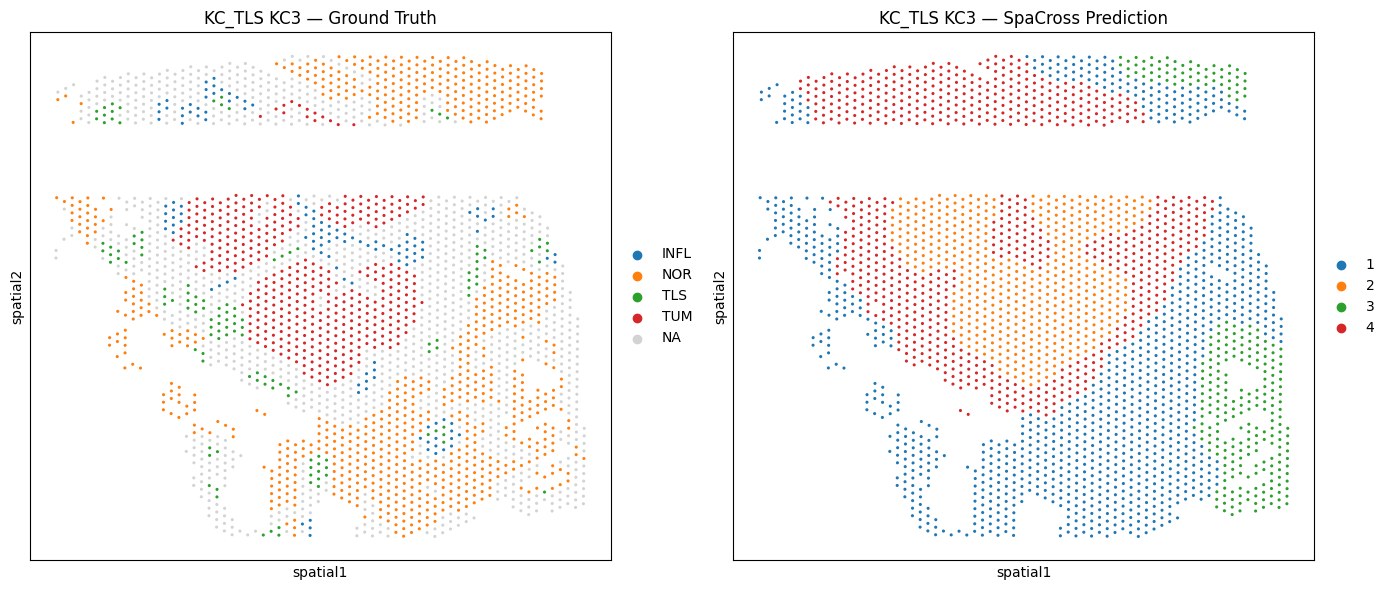

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/K")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/klc_tls_spacross/K")

SAMPLE_ID = "KC3"   # "KC2" or "KC3"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample {SAMPLE_ID}. "
        f"Available samples: {available}"
    )

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"KC_TLS {SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"KC_TLS {SAMPLE_ID} — SpaCross Prediction",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Running results summary

import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/klc_tls_spacross/K")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance["sample"] = performance["sample"].astype(str)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "dataset", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model",
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All KC_TLS SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "running_time_sec"] if c in performance.columns]
display(performance[summary_cols].describe())

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All KC_TLS SpaCross results =====


,dataset,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,KC_TLS_10x,KC1,0,0.955297,0.865225,0.869872,0.040865,3,3690,1447,15.46,mclust,NVIDIA A30
1,KC_TLS_10x,KC2,0,0.015378,0.022483,0.022838,0.048044,3,1870,777,9.72,mclust,NVIDIA A30
2,KC_TLS_10x,KC3,0,0.451177,0.536868,0.542300,0.037285,3,2654,1541,11.07,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,3.000000,3.000000,3.000000,3.000000,3.000000
mean,0.473951,0.474859,0.478336,0.042065,12.083333
std,0.470373,0.424779,0.427125,0.005479,3.001172
min,0.015378,0.022483,0.022838,0.037285,9.720000
25%,0.233278,0.279676,0.282569,0.039075,10.395000
50%,0.451177,0.536868,0.542300,0.040865,11.070000
75%,0.703237,0.701046,0.706086,0.044454,13.265000
max,0.955297,0.865225,0.869872,0.048044,15.460000



===== Mean metrics =====
Mean ARI: 0.4740
Mean NMI: 0.4749
Mean ACC: 0.4783
Mean DIS: 0.0421

===== Best / worst ARI =====
Best ARI : KC1  ARI=0.9553
Worst ARI: KC2  ARI=0.0154


In [ ]:
# actual layer in ground truth checking
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/K")

ALL_KC_TLS_SAMPLES = [
    "KC1",
    "KC2",
    "KC3",
]

results = []

for sample_id in ALL_KC_TLS_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values("n_classes")

print("===== KC_TLS_10x: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== KC_TLS_10x: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
0,KC1,4,"[INFL, NOR, TLS, TUM]",3690,1447,2243
1,KC2,4,"[INFL, NOR, TLS, TUM]",1870,777,1093
2,KC3,4,"[INFL, NOR, TLS, TUM]",2654,1541,1113



===== Summary =====
n_classes
4    3
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'KC1': 4, 'KC2': 4, 'KC3': 4}
